In [1]:
from plottr.data.datadict_storage import datadict_from_hdf5
import numpy as np
import matplotlib.pyplot as plt
import lmfit
import scipy.constants as spc

In [2]:
def S11_resonator(freq, fc, ke, ki, a0, a1, Poff, ed):
    numer = 1j*(freq-fc)+(ke-ki)/2
    denom = 1j*(freq-fc)-(ke+ki)/2
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(-Poff-ed*2*np.pi*freq))).conj()
    return model

In [3]:
header = "D:/K_sunada/result/CDY151/"
data = "/2023-11-06/2023-11-06T102840_d0d3eb31-cw_sparameter"
dd = datadict_from_hdf5(header + data +"/data")

In [4]:
s11 = dd['s21']['values']
s11_real = dd['s21']['values'].real
s11_imag = dd['s21']['values'].imag
freq = dd['frequency']['values']

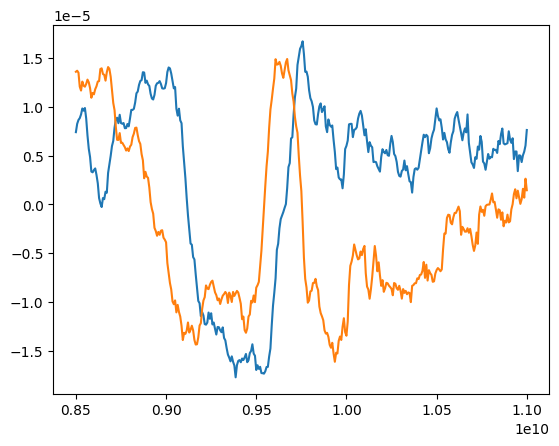

In [5]:
# plt.plot(freq, s11)
plt.plot(freq, s11_real)
plt.plot(freq, s11_imag)
plt.show()

In [6]:
par_ini = {
    'fc':9.71e9,
    'ke':0.030*1e9,
    'ki':0.0001*1e9,
    'a0':3.9356e-06,
    'a1':0.000001,
    'Poff':np.pi/2,
    'ed':0,
}

par_min = {
    'fc':0,
    'ke':0,
    'ki':0,
    'a0':- np.inf,
    'a1':- np.inf,
    'Poff':- np.pi,
    'ed':- np.inf,
}

par_max = {
    'fc':np.inf,
    'ke':np.inf,
    'ki':np.inf,
    'a0':np.inf,
    'a1':np.inf,
    'Poff':np.pi,
    'ed':np.inf,
}

par_vary = {
    'fc':True,
    'ke':True,
    'ki':True,
    'a0':True,
    'a1':True,
    'Poff':True,
    'ed':True,
}

In [7]:
model = lmfit.Model(S11_resonator)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )

In [8]:
res = model.fit(data = s11, params = params, freq = freq)
res

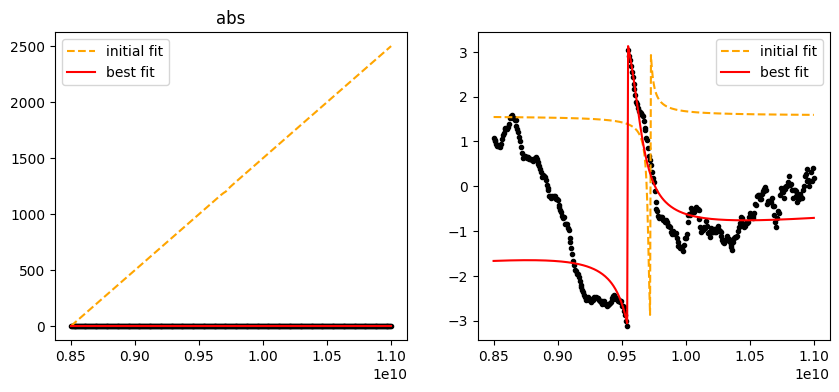

In [9]:
res = model.fit(data = s11, params = params, freq = freq)

fig, ax = plt.subplots(1,2,figsize=(10,4))
ax[0].plot(freq, np.abs(s11), '.', color='k')
ax[0].plot(freq, np.abs(res.init_fit), '--', label='initial fit', color='orange')
ax[0].plot(freq, np.abs(res.best_fit), '-', label='best fit', color='red')
ax[0].set_title('abs')
ax[0].legend()
ax[1].plot(freq, np.angle(s11), '.', color='k')
ax[1].plot(freq, np.angle(res.init_fit), '--', label='initial fit', color='orange')
ax[1].plot(freq, np.angle(res.best_fit), '-', label='best fit', color='red')
ax[1].legend()


plt.show()

dpr

In [15]:
header = "D:/K_sunada/result/CDY151/"
data = "/2023-11-06/2023-11-06T114124_f9ca5e1b-cw_sparameter"
dd = datadict_from_hdf5(header + data +"/data")
s11 = dd['s21']['values']

freq = dd['frequency']['values']* 1e-9

In [56]:
def S11_dpr_model(freq, fr, ff, kf_e, kf_i, gamma, g, a0, a1, Poff,ed):
    numer = (1j*(freq-ff)+(kf_e-kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    denom = (1j*(freq-ff)-(kf_e+kf_i)/2)*(1j*(freq-fr)-gamma/2) + (g**2)
    model = (numer/denom * (a0+a1*(freq-freq[0])) * np.exp(1j*(Poff-ed*2*np.pi*freq))).conj()
    return model

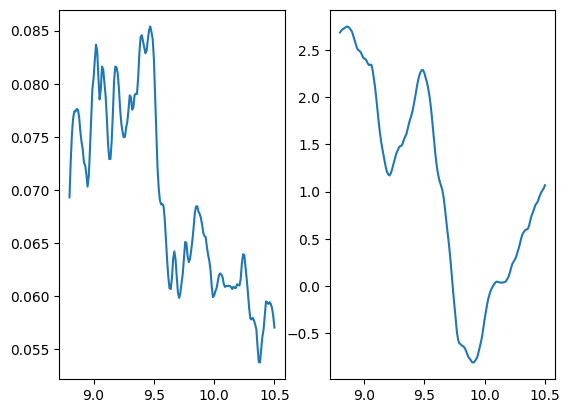

In [18]:

fig,ax = plt.subplots(1,2)
ax[0].plot(freq,np.abs(s11))
ax[1].plot(freq,np.angle(s11))

In [82]:
par_ini = {'fr': 9.2,  'ff': 9.65,    'kf_e': 130e-3,   'kf_i': 0,  'g': 190e-3, 'gamma': 0,
           'a0': 1,  'a1': 0,        'Poff': -31,   'ed': 0.}
par_min = {'fr': 0,     'ff': 0,        'kf_e': 0,        'kf_i': 0,        'g': 0,     'gamma': 0,
           'a0': 0,     'a1': -np.inf,  'Poff': -np.inf,'ed': -np.inf}
par_max = {'fr': np.inf,'ff': np.inf,   'kf_e': np.inf,   'kf_i': np.inf,   'g': np.inf,'gamma': np.inf,
           'a0': np.inf,'a1': np.inf,   'Poff': np.inf, 'ed': np.inf}
par_var = {'fr': True, 'ff': True,    'kf_e': True,    'kf_i': True,    'g': True, 'gamma': False,
           'a0': False, 'a1': False,    'Poff': True,  'ed': False}

model=lmfit.Model(S11_dpr_model)
params = model.make_params()

for name in list(par_ini):
    params[name].set(value=par_ini[name])
    
for name in list(par_min):
    params[name].set(min=par_min[name])
    
for name in list(par_max):
    params[name].set(max=par_max[name])
    
for name in list(par_var):
    params[name].set(vary=par_var[name])

result = model.fit(freq=freq, data=s11, params=params, method='leastsq')



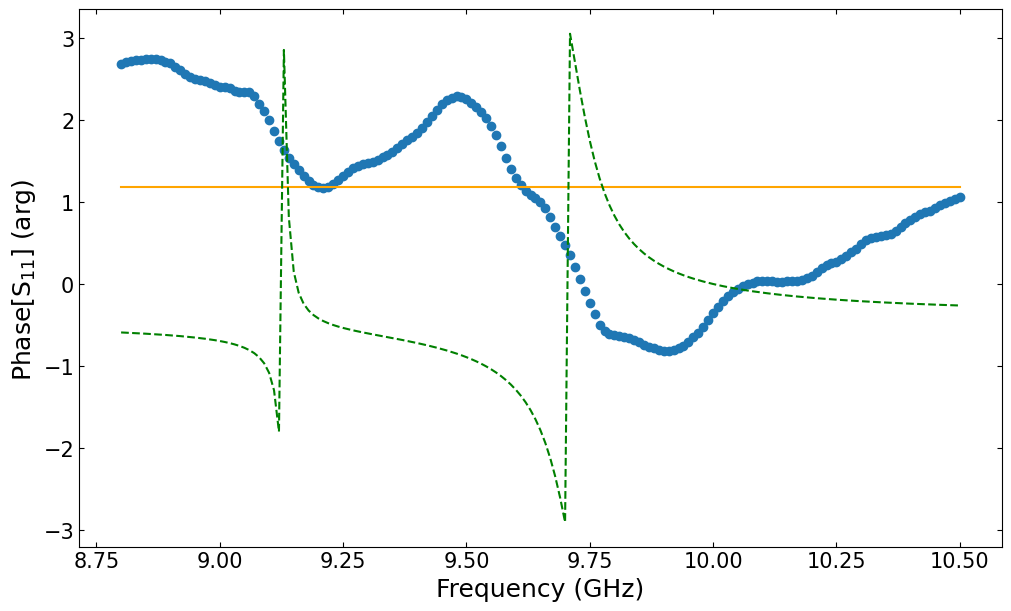

In [83]:
fig, ax = plt.subplots(figsize=(10,6),constrained_layout=True)
plt.rcParams["font.size"] = 15
ax.set_xlabel('Frequency (GHz)',fontsize=18)
ax.set_ylabel('Phase[S$_{11}$] (arg) ', fontsize=18)
# ax.tick_params(direction='in')
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
# ax1.set_xlim(0, 250000)
# ax1.set_ylim(-48, 160)

plt.tick_params(
            top='on',
            bottom='on`',
            left='on',
            right='on',
            )

ax.plot(freq,np.angle(s11), ls='', marker='o')
ax.plot(freq,np.angle(result.best_fit), color='orange')
ax.plot(freq,np.angle(result.init_fit), color='green', ls='--', )
# ax[1][0].plot(freq,np.abs(s11) - np.abs(result.best_fit), ls='', marker='.')
# error_phi = np.angle(s11) - np.angle(result.best_fit)
# error_phi[error_phi>np.pi] -= 2*np.pi
# error_phi[error_phi<-np.pi] += 2*np.pi
# ax[1][1].plot(freq,error_phi, ls='', marker='.')

result

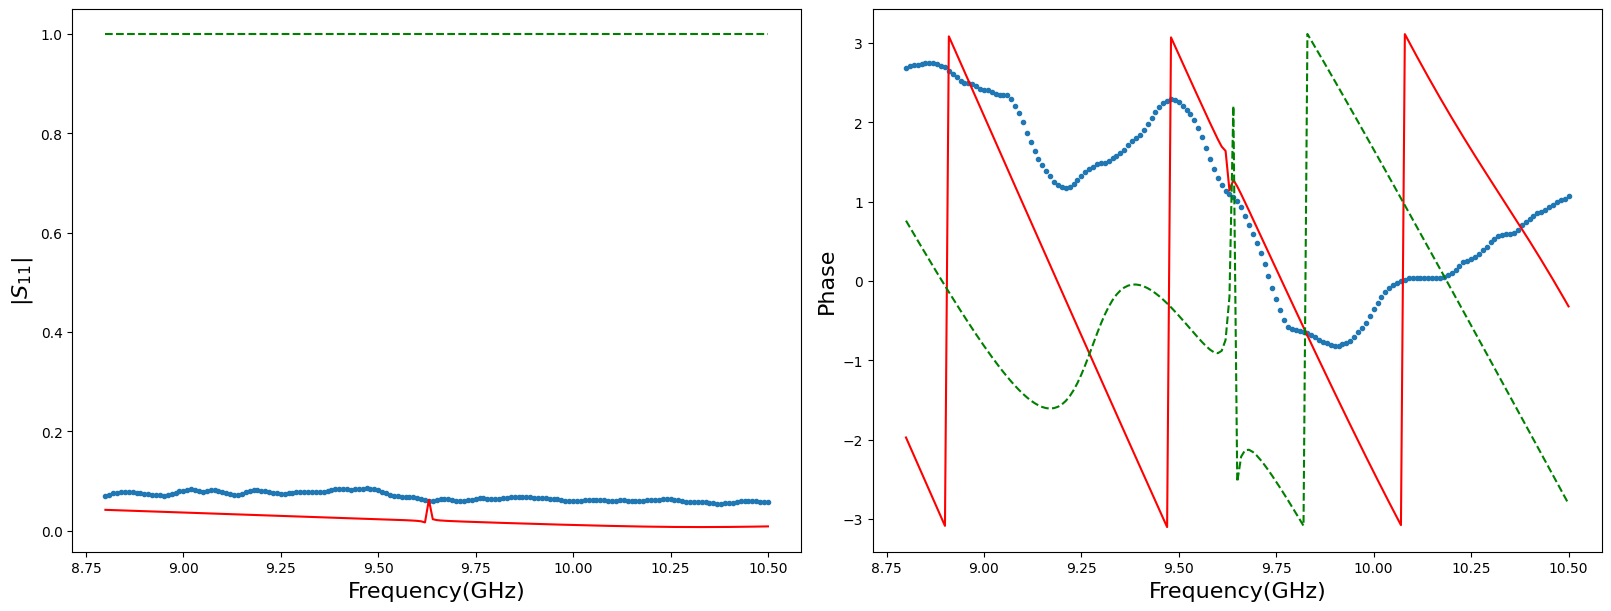

In [21]:
fig, ax = plt.subplots(1,2,figsize=(16,6),constrained_layout=True)
ax[0].set_xlabel('Frequency(GHz)',fontsize=16)
ax[0].set_ylabel(r'$|S_{11}|$', fontsize=16)
ax[1].set_xlabel('Frequency(GHz)',fontsize=16)
ax[1].set_ylabel('Phase', fontsize=16)
# ax.tick_params(direction='in')

ax[0].plot(freq,np.abs(s11), ls='', marker='.')
ax[0].plot(freq,np.abs(result.best_fit), color='red')
ax[0].plot(freq,np.abs(result.init_fit), color='green', ls='--', marker='')
ax[1].plot(freq,np.angle(s11), ls='', marker='.')
ax[1].plot(freq,np.angle(result.best_fit), color='red')
ax[1].plot(freq,np.angle(result.init_fit), color='green', ls='--', )
# ax[1][0].plot(freq,np.abs(s11) - np.abs(result.best_fit), ls='', marker='.')
# error_phi = np.angle(s11) - np.angle(result.best_fit)
# error_phi[error_phi>np.pi] -= 2*np.pi
# error_phi[error_phi<-np.pi] += 2*np.pi
# ax[1][1].plot(freq,error_phi, ls='', marker='.')

result

平均光子数

In [ ]:
def ave_photon_number(Power, k_ex, k_in, omega_r, omega_p):
    n = (k_ex/(((k_in + k_ex)/2)**2 + (omega_r - omega_p)**2))*(Power/(spc.hbar * omega_p))
    return n

In [ ]:
spc.hbar

1.0545718176461565e-34

In [ ]:
k_ex = 0.16421957e9*(2*np.pi)
k_in = 1.4433e-5*(2*np.pi)

omega_r = 10.2378262e9*2*np.pi
omega_p = 10.3e9*2*np.pi

Power =  10**((-23-10-50-20)/10) *1e-3#J/s

ave_photon_number(Power, k_ex, k_in, omega_r, omega_p)


18.09400588408793

In [ ]:
kai = (10.307e9-10.284e9)*2*np.pi/2
delta = (10.1565429e9-8.175e9)*2*np.pi
g = (kai*delta)**0.5
g

948485133.3743819

In [ ]:
delta**2/(4*g**2)

43.0770195652174

In [ ]:
k_ex

26136356.317925524

In [ ]:
delta = omega_p - 8.02e9*2*np.pi
g = 

SyntaxError: invalid syntax (1728028817.py, line 1)

In [ ]:
Power, omega_p, omega_r, k_ex, k_in

In [ ]:
1/(10.209-10.066)